In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/Users/hugocather/MD4002 Dissertation/2024/Cleaned results/2024_Dataset_Cleaned_For_Analysis.csv")

print(f"Dataset: {df.shape[0]} practices across {df['HBT'].nunique()} Health Boards")
print(f"\nPractices per board:")
print(df['Board_Name'].value_counts().sort_index().to_string())

Dataset: 807 practices across 14 Health Boards

Practices per board:
Board_Name
NHS Ayrshire & Arran            48
NHS Borders                     20
NHS Dumfries & Galloway         26
NHS Fife                        50
NHS Forth Valley                39
NHS Grampian                    63
NHS Greater Glasgow & Clyde    207
NHS Highland                    88
NHS Lanarkshire                 89
NHS Lothian                    104
NHS Orkney                       6
NHS Shetland                     8
NHS Tayside                     51
NHS Western Isles                8


In [8]:
# Standardise predictors (z-scores) for comparability of coefficients

df['Weighted_SIMD_z'] = stats.zscore(df['Weighted_SIMD'])
df['Elderly_Pct_z'] = stats.zscore(df['Elderly (65+) - % of Total'])
df['Overall_Pct_Female_z'] = stats.zscore(df['Overall_Pct_Female'])
df['Clinical_Need_Composite_z'] = stats.zscore(df['Clinical_Need_Composite'])
df['PracticeListSize_z'] = stats.zscore(df['PracticeListSize'])

print("Standardised variables created. Descriptive stats:")
z_cols = ['Weighted_SIMD_z', 'Elderly_Pct_z', 'Overall_Pct_Female_z', 
          'Clinical_Need_Composite_z', 'PracticeListSize_z']
print(df[z_cols].describe().round(3).to_string())

Standardised variables created. Descriptive stats:
       Weighted_SIMD_z  Elderly_Pct_z  Overall_Pct_Female_z  Clinical_Need_Composite_z  PracticeListSize_z
count          807.000        807.000               807.000                    807.000             807.000
mean            -0.000         -0.000                 0.000                     -0.000               0.000
std              1.001          1.001                 1.001                      1.001               1.001
min             -2.124         -2.420                -8.254                     -3.205              -1.660
25%             -0.731         -0.664                -0.277                     -0.596              -0.734
50%             -0.019         -0.032                 0.178                      0.047              -0.118
75%              0.656          0.630                 0.542                      0.621               0.559
max              2.409          3.992                 4.008                      5.306       

In [11]:
# Fit the NULL (empty) multilevel model — no predictors, random intercept only

null_model = smf.mixedlm(
    "Log_Total_DDDs ~ 1",
    data=df,
    groups=df["HBT"]
).fit()

print("=" * 80)
print("MODEL 0: NULL MODEL (Random Intercept Only)")
print("=" * 80)
print(null_model.summary())

# Variance decomposition
sigma2_u_null = null_model.cov_re.iloc[0, 0]  # Between-board variance
sigma2_e_null = null_model.scale              # Within-board variance
icc_null = sigma2_u_null / (sigma2_u_null + sigma2_e_null)

# --- Model fit statistics ---
print(f"\n--- Model Fit ---")
print(f"AIC: {null_model.aic:.4f}")
print(f"BIC: {null_model.bic:.4f}")
print(f"Log-Likelihood: {null_model.llf:.4f}")

print(f"\n--- Variance Decomposition ---")
print(f"Between-Board variance (σ²_u): {sigma2_u_null:.4f}")
print(f"Within-Board variance (σ²_e):  {sigma2_e_null:.4f}")
print(f"Total variance:                {sigma2_u_null + sigma2_e_null:.4f}")
print(f"ICC: {icc_null:.4f} ({icc_null*100:.1f}%)")
print(f"\nInterpretation: {icc_null*100:.1f}% of the variance in prescribing")
print(f"sits between Health Boards, justifying multilevel modelling.")

MODEL 0: NULL MODEL (Random Intercept Only)
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Log_Total_DDDs
No. Observations: 807     Method:             REML          
No. Groups:       14      Scale:              0.2024        
Min. group size:  6       Log-Likelihood:     -525.4248     
Max. group size:  207     Converged:          Yes           
Mean group size:  57.6                                      
-------------------------------------------------------------
               Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept      7.098     0.111  64.057  0.000   6.881   7.316
Group Var      0.163     0.153                               


--- Model Fit ---
AIC: nan
BIC: nan
Log-Likelihood: -525.4248

--- Variance Decomposition ---
Between-Board variance (σ²_u): 0.1628
Within-Board variance (σ²_e):  0.2024
Total variance:                0.3652
ICC: 0.4458 (44.6%)



In [13]:
# MODEL 1 — Deprivation only (random intercept)

model1 = smf.mixedlm(
    "Log_Total_DDDs ~ Weighted_SIMD_z",
    data=df,
    groups=df["HBT"]
).fit()

print("=" * 80)
print("MODEL 1: DEPRIVATION ONLY (SIMD)")
print("=" * 80)
print(model1.summary())

sigma2_u_m1 = model1.cov_re.iloc[0, 0]
sigma2_e_m1 = model1.scale

# Proportional change in variance vs null
pcv_board_m1 = (sigma2_u_null - sigma2_u_m1) / sigma2_u_null
pcv_practice_m1 = (sigma2_e_null - sigma2_e_m1) / sigma2_e_null

# --- Model fit statistics ---
print(f"\n--- Model Fit ---")
print(f"AIC: {model1.aic:.4f}")
print(f"BIC: {model1.bic:.4f}")
print(f"Log-Likelihood: {model1.llf:.4f}")

print(f"\n--- Variance Decomposition ---")
print(f"Between-Board variance (σ²_u): {sigma2_u_m1:.4f}")
print(f"Within-Board variance (σ²_e):  {sigma2_e_m1:.4f}")
print(f"ICC: {sigma2_u_m1 / (sigma2_u_m1 + sigma2_e_m1):.4f}")
print(f"\n--- Proportional Change in Variance (vs Null) ---")
print(f"Board-level PCV:    {pcv_board_m1:.4f} ({pcv_board_m1*100:.1f}% of Board variance explained)")
print(f"Practice-level PCV: {pcv_practice_m1:.4f} ({pcv_practice_m1*100:.1f}% of practice variance explained)")

MODEL 1: DEPRIVATION ONLY (SIMD)
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Log_Total_DDDs
No. Observations: 807     Method:             REML          
No. Groups:       14      Scale:              0.1286        
Min. group size:  6       Log-Likelihood:     -344.8600     
Max. group size:  207     Converged:          Yes           
Mean group size:  57.6                                      
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         7.148    0.085  84.346 0.000  6.982  7.314
Weighted_SIMD_z  -0.312    0.015 -21.533 0.000 -0.341 -0.284
Group Var         0.095    0.114                            


--- Model Fit ---
AIC: nan
BIC: nan
Log-Likelihood: -344.8600

--- Variance Decomposition ---
Between-Board variance (σ²_u): 0.0946
Within-Board variance (σ²_e):  0.1286
ICC: 0.4239

-

In [15]:
# MODEL 2 — Deprivation + Demographics (Elderly, Female)

model2 = smf.mixedlm(
    "Log_Total_DDDs ~ Weighted_SIMD_z + Elderly_Pct_z + Overall_Pct_Female_z",
    data=df,
    groups=df["HBT"]
).fit()

print("=" * 80)
print("MODEL 2: SIMD + DEMOGRAPHICS (Elderly + Female)")
print("=" * 80)
print(model2.summary())

sigma2_u_m2 = model2.cov_re.iloc[0, 0]
sigma2_e_m2 = model2.scale

pcv_board_m2 = (sigma2_u_null - sigma2_u_m2) / sigma2_u_null
pcv_practice_m2 = (sigma2_e_null - sigma2_e_m2) / sigma2_e_null

# --- Model fit statistics ---
print(f"\n--- Model Fit ---")
print(f"AIC: {model2.aic:.4f}")
print(f"BIC: {model2.bic:.4f}")
print(f"Log-Likelihood: {model2.llf:.4f}")

print(f"\n--- Variance Decomposition ---")
print(f"Between-Board variance (σ²_u): {sigma2_u_m2:.4f}")
print(f"Within-Board variance (σ²_e):  {sigma2_e_m2:.4f}")
print(f"ICC: {sigma2_u_m2 / (sigma2_u_m2 + sigma2_e_m2):.4f}")
print(f"\n--- Proportional Change in Variance (vs Null) ---")
print(f"Board-level PCV:    {pcv_board_m2:.4f} ({pcv_board_m2*100:.1f}% of Board variance explained)")
print(f"Practice-level PCV: {pcv_practice_m2:.4f} ({pcv_practice_m2*100:.1f}% of practice variance explained)")

MODEL 2: SIMD + DEMOGRAPHICS (Elderly + Female)
             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  Log_Total_DDDs
No. Observations:   807      Method:              REML          
No. Groups:         14       Scale:               0.1126        
Min. group size:    6        Log-Likelihood:      -299.5176     
Max. group size:    207      Converged:           Yes           
Mean group size:    57.6                                        
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             7.088    0.097  73.207 0.000  6.898  7.277
Weighted_SIMD_z      -0.374    0.015 -25.225 0.000 -0.403 -0.345
Elderly_Pct_z         0.151    0.017   8.958 0.000  0.118  0.184
Overall_Pct_Female_z  0.051    0.013   3.895 0.000  0.025  0.077
Group Var             0.125    0.159                    

In [16]:
# MODEL 3 — Full model (all predictors)

model3 = smf.mixedlm(
    "Log_Total_DDDs ~ Weighted_SIMD_z + Elderly_Pct_z + Overall_Pct_Female_z + Clinical_Need_Composite_z + PracticeListSize_z",
    data=df,
    groups=df["HBT"]
).fit()

print("=" * 80)
print("MODEL 3: FULL MODEL (SIMD + Elderly + Female + Clinical Need + List Size)")
print("=" * 80)
print(model3.summary())

sigma2_u_m3 = model3.cov_re.iloc[0, 0]
sigma2_e_m3 = model3.scale

pcv_board_m3 = (sigma2_u_null - sigma2_u_m3) / sigma2_u_null
pcv_practice_m3 = (sigma2_e_null - sigma2_e_m3) / sigma2_e_null

# --- Model fit statistics ---
print(f"\n--- Model Fit ---")
print(f"AIC: {model3.aic:.4f}")
print(f"BIC: {model3.bic:.4f}")
print(f"Log-Likelihood: {model3.llf:.4f}")

print(f"\n--- Variance Decomposition ---")
print(f"Between-Board variance (σ²_u): {sigma2_u_m3:.4f}")
print(f"Within-Board variance (σ²_e):  {sigma2_e_m3:.4f}")
print(f"ICC: {sigma2_u_m3 / (sigma2_u_m3 + sigma2_e_m3):.4f} ({sigma2_u_m3 / (sigma2_u_m3 + sigma2_e_m3)*100:.1f}%)")
print(f"\n--- Proportional Change in Variance (vs Null) ---")
print(f"Board-level PCV:    {pcv_board_m3:.4f} ({pcv_board_m3*100:.1f}% of Board variance explained)")
print(f"Practice-level PCV: {pcv_practice_m3:.4f} ({pcv_practice_m3*100:.1f}% of practice variance explained)")

MODEL 3: FULL MODEL (SIMD + Elderly + Female + Clinical Need + List Size)
                Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Log_Total_DDDs
No. Observations:    807        Method:                REML          
No. Groups:          14         Scale:                 0.1111        
Min. group size:     6          Log-Likelihood:        -299.4481     
Max. group size:     207        Converged:             Yes           
Mean group size:     57.6                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  7.092    0.093  76.004 0.000  6.909  7.275
Weighted_SIMD_z           -0.382    0.016 -23.494 0.000 -0.413 -0.350
Elderly_Pct_z              0.166    0.022   7.597 0.000  0.124  0.209
Overall_Pct_Female_z       0.043

In [17]:
# Full model for strong and weak opioids
# Null models for each outcome (needed for PCV calculation)
null_strong = smf.mixedlm("Log_Strong_DDDs ~ 1", data=df, groups=df["HBT"]).fit()
null_weak   = smf.mixedlm("Log_Weak_DDDs ~ 1",   data=df, groups=df["HBT"]).fit()

sigma2_u_null_s = null_strong.cov_re.iloc[0, 0]
sigma2_e_null_s = null_strong.scale
sigma2_u_null_w = null_weak.cov_re.iloc[0, 0]
sigma2_e_null_w = null_weak.scale

# --- Full models ---
formula = "~ Weighted_SIMD_z + Elderly_Pct_z + Overall_Pct_Female_z + Clinical_Need_Composite_z + PracticeListSize_z"

model_strong = smf.mixedlm("Log_Strong_DDDs" + formula, data=df, groups=df["HBT"]).fit()
model_weak   = smf.mixedlm("Log_Weak_DDDs"   + formula, data=df, groups=df["HBT"]).fit()

# --- Variance decomposition function ---
def variance_summary(model, null_u, null_e, label):
    u = model.cov_re.iloc[0, 0]
    e = model.scale
    icc = u / (u + e)
    pcv_u = (null_u - u) / null_u
    pcv_e = (null_e - e) / null_e
    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"{'='*70}")
    print(model.summary())
    print(f"\n--- Variance Decomposition ---")
    print(f"  Between-Board variance (σ²_u): {u:.4f}  |  PCV vs null: {pcv_u*100:.1f}%")
    print(f"  Within-Board variance  (σ²_e): {e:.4f}  |  PCV vs null: {pcv_e*100:.1f}%")
    print(f"  ICC: {icc:.4f} ({icc*100:.1f}%)")
    print(f"  Log-Likelihood: {model.llf:.2f}")

variance_summary(model_strong, sigma2_u_null_s, sigma2_e_null_s, "FULL MODEL — STRONG OPIOIDS (Log_Strong_DDDs)")
variance_summary(model_weak,   sigma2_u_null_w, sigma2_e_null_w, "FULL MODEL — WEAK OPIOIDS (Log_Weak_DDDs)")

# --- Side-by-side coefficient comparison across all three outcomes ---
print(f"\n{'='*70}")
print("  COEFFICIENT COMPARISON: Total vs Strong vs Weak Opioids")
print(f"{'='*70}")

predictors = ['Intercept', 'Weighted_SIMD_z', 'Elderly_Pct_z',
              'Overall_Pct_Female_z', 'Clinical_Need_Composite_z', 'PracticeListSize_z']

coef_comparison = pd.DataFrame({
    'Total β':  model3.fe_params[predictors].round(4),
    'Total SE': model3.bse[predictors].round(4),
    'Strong β': model_strong.fe_params[predictors].round(4),
    'Strong SE':model_strong.bse[predictors].round(4),
    'Weak β':   model_weak.fe_params[predictors].round(4),
    'Weak SE':  model_weak.bse[predictors].round(4),
})

print(coef_comparison.to_string())
print("\nNote: Coefficients are standardised (z-score predictors) — directly comparable across models.")


  FULL MODEL — STRONG OPIOIDS (Log_Strong_DDDs)
                Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   Log_Strong_DDDs
No. Observations:     807       Method:               REML           
No. Groups:           14        Scale:                0.1705         
Min. group size:      6         Log-Likelihood:       -463.1861      
Max. group size:      207       Converged:            Yes            
Mean group size:      57.6                                           
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  5.332    0.063  84.330 0.000  5.209  5.456
Weighted_SIMD_z           -0.392    0.020 -19.589 0.000 -0.431 -0.352
Elderly_Pct_z              0.227    0.027   8.463 0.000  0.174  0.279
Overall_Pct_Female_z       0.018    0.017   1.099 0.272 -

In [18]:
# Model comparison table — summarise all models side by side

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

comparison = pd.DataFrame({
    'Model': ['Null', 'M1: SIMD', 'M2: SIMD + Demographics', 'M3: Full Model'],
    'Board Var (σ²_u)': [sigma2_u_null, sigma2_u_m1, sigma2_u_m2, sigma2_u_m3],
    'Practice Var (σ²_e)': [sigma2_e_null, sigma2_e_m1, sigma2_e_m2, sigma2_e_m3],
    'ICC': [
        icc_null,
        sigma2_u_m1 / (sigma2_u_m1 + sigma2_e_m1),
        sigma2_u_m2 / (sigma2_u_m2 + sigma2_e_m2),
        sigma2_u_m3 / (sigma2_u_m3 + sigma2_e_m3)
    ],
    'Board PCV': [0, pcv_board_m1, pcv_board_m2, pcv_board_m3],
    'Practice PCV': [0, pcv_practice_m1, pcv_practice_m2, pcv_practice_m3],
    'Log-Likelihood': [null_model.llf, model1.llf, model2.llf, model3.llf]
})

comparison['ICC'] = comparison['ICC'].map('{:.1%}'.format)
comparison['Board PCV'] = comparison['Board PCV'].map('{:.1%}'.format)
comparison['Practice PCV'] = comparison['Practice PCV'].map('{:.1%}'.format)
comparison = comparison.set_index('Model')
print(comparison.round(4).to_string())

MODEL COMPARISON SUMMARY
                         Board Var (σ²_u)  Practice Var (σ²_e)    ICC Board PCV Practice PCV  Log-Likelihood
Model                                                                                                       
Null                               0.1628               0.2024  44.6%      0.0%         0.0%       -525.4248
M1: SIMD                           0.0946               0.1286  42.4%     41.9%        36.5%       -344.8600
M2: SIMD + Demographics            0.1253               0.1126  52.7%     23.0%        44.4%       -299.5176
M3: Full Model                     0.1161               0.1111  51.1%     28.7%        45.1%       -299.4481


In [19]:
# Fit OLS regression model 

ols_formula = 'Log_Total_DDDs ~ Weighted_SIMD_z + Elderly_Pct_z + Overall_Pct_Female_z + Clinical_Need_Composite_z + PracticeListSize_z'

ols_model = smf.ols(ols_formula, data=df).fit()

print("=" * 80)
print("OLS MULTIPLE REGRESSION RESULTS")
print("=" * 80)
print(ols_model.summary())

OLS MULTIPLE REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:         Log_Total_DDDs   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     160.9
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          2.49e-118
Time:                        19:15:04   Log-Likelihood:                -407.30
No. Observations:                 807   AIC:                             826.6
Df Residuals:                     801   BIC:                             854.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [20]:
# Compare OLS vs Multilevel coefficients and standard errors

print("=" * 80)
print("OLS vs MULTILEVEL MODEL COMPARISON")
print("=" * 80)

predictors = ['Intercept', 'Weighted_SIMD_z', 'Elderly_Pct_z', 
              'Overall_Pct_Female_z', 'Clinical_Need_Composite_z', 'PracticeListSize_z']

comparison_df = pd.DataFrame({
    'OLS Coef': ols_model.params[predictors],
    'OLS SE': ols_model.bse[predictors],
    'MLM Coef': model3.fe_params[predictors],
    'MLM SE': model3.bse[predictors],
    'SE Ratio (MLM/OLS)': model3.bse[predictors] / ols_model.bse[predictors]
}).round(4)

print(comparison_df.to_string())
print("\nSE Ratio > 1 means OLS underestimates uncertainty (overconfident)")
print("SE Ratio < 1 means OLS overestimates uncertainty")
print("\nThe intercept SE ratio is particularly large because OLS ignores")
print("the board-level clustering that the multilevel model accounts for.")

OLS vs MULTILEVEL MODEL COMPARISON
                           OLS Coef  OLS SE  MLM Coef  MLM SE  SE Ratio (MLM/OLS)
Intercept                    7.2228  0.0142    7.0919  0.0933              6.5885
Weighted_SIMD_z             -0.4535  0.0173   -0.3816  0.0162              0.9400
Elderly_Pct_z                0.1116  0.0217    0.1664  0.0219              1.0076
Overall_Pct_Female_z         0.0779  0.0159    0.0432  0.0135              0.8518
Clinical_Need_Composite_z   -0.0191  0.0198   -0.0016  0.0169              0.8534
PracticeListSize_z           0.0783  0.0158    0.0498  0.0138              0.8731

SE Ratio > 1 means OLS underestimates uncertainty (overconfident)
SE Ratio < 1 means OLS overestimates uncertainty

The intercept SE ratio is particularly large because OLS ignores
the board-level clustering that the multilevel model accounts for.


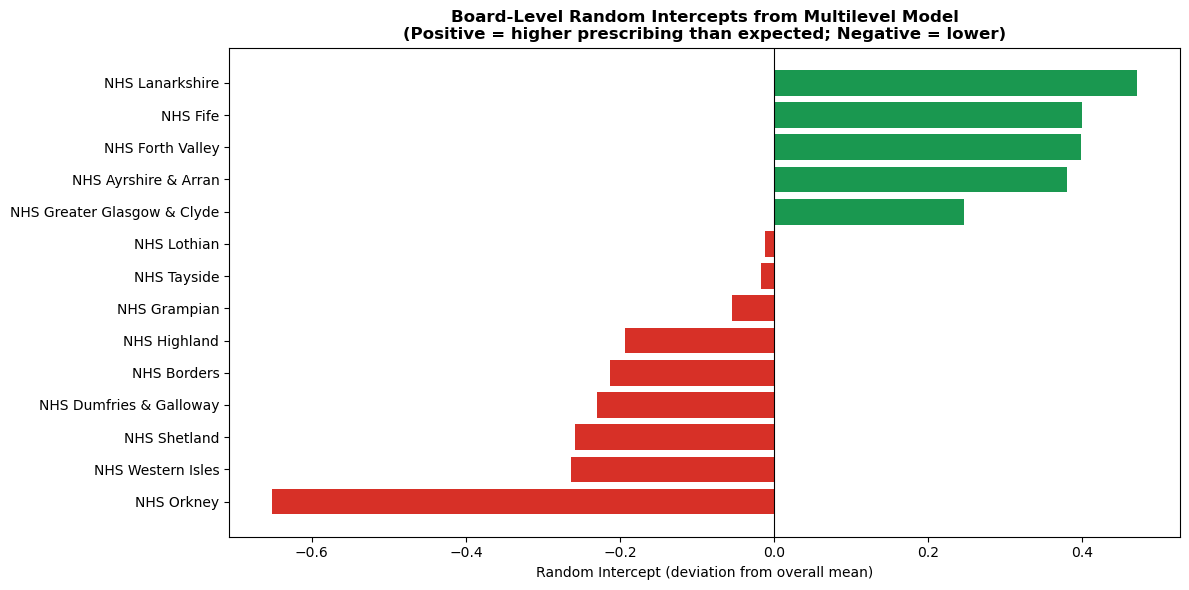

Random Intercepts by Board:
                      Board  Random_Intercept
                 NHS Orkney         -0.651382
          NHS Western Isles         -0.264254
               NHS Shetland         -0.257917
    NHS Dumfries & Galloway         -0.230477
                NHS Borders         -0.213612
               NHS Highland         -0.193280
               NHS Grampian         -0.055214
                NHS Tayside         -0.016993
                NHS Lothian         -0.011656
NHS Greater Glasgow & Clyde          0.245837
       NHS Ayrshire & Arran          0.380153
           NHS Forth Valley          0.398696
                   NHS Fife          0.399525
            NHS Lanarkshire          0.470576


In [21]:
# Extract and plot random intercepts by Health Board

random_effects = pd.DataFrame({
    'Board': [df[df['HBT'] == k]['Board_Name'].iloc[0] for k in model3.random_effects.keys()],
    'Random_Intercept': [v['Group'] for v in model3.random_effects.values()]
})
random_effects = random_effects.sort_values('Random_Intercept')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d73027' if x < 0 else '#1a9850' for x in random_effects['Random_Intercept']]
ax.barh(random_effects['Board'], random_effects['Random_Intercept'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Random Intercept (deviation from overall mean)')
ax.set_title('Board-Level Random Intercepts from Multilevel Model\n'
             '(Positive = higher prescribing than expected; Negative = lower)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/MLM_Random_Intercepts.png",
            dpi=300, bbox_inches='tight')
plt.show()

print("Random Intercepts by Board:")
print(random_effects.to_string(index=False))

/var/folders/5y/k7hgywdn7zxg81ddyb_trqy80000gn/T/ipykernel_10967/3166506850.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=board_col, y='MLM_Residual', order=board_order,


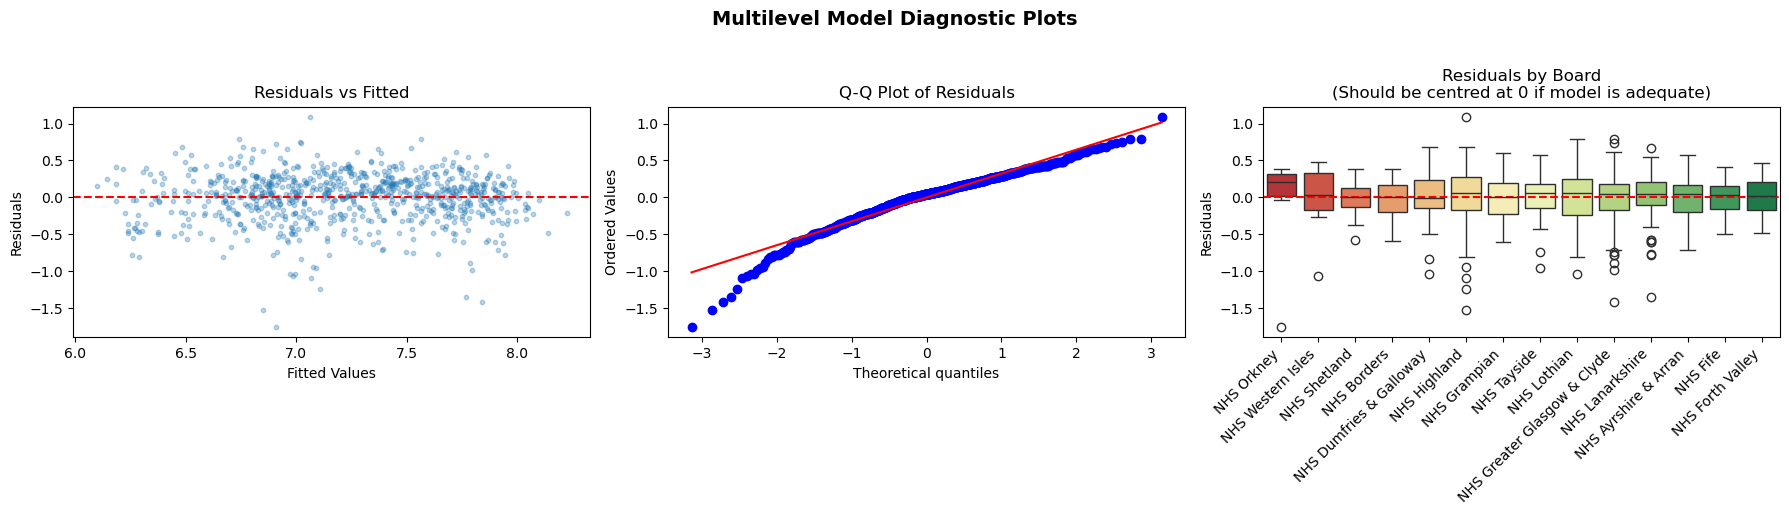

ANOVA of MLM residuals by Board: F = 0.0675, p = 1.0000
(Non-significant = clustering has been accounted for by the random intercept)


In [22]:
# Multilevel model diagnostic plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mlm_resid = model3.resid
mlm_fitted = model3.fittedvalues

# Plot 1: Residuals vs Fitted
axes[0].scatter(mlm_fitted, mlm_resid, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Plot 2: Q-Q plot
stats.probplot(mlm_resid, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Plot 3: Residuals by Board (check if clustering is resolved)
df['MLM_Residual'] = mlm_resid
board_col = 'Board_Name'
board_order = df.groupby(board_col)['MLM_Residual'].mean().sort_values().index.tolist()
sns.boxplot(data=df, x=board_col, y='MLM_Residual', order=board_order, 
            ax=axes[2], palette='RdYlGn', showfliers=True)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_xlabel('')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals by Board\n(Should be centred at 0 if model is adequate)')
axes[2].tick_params(axis='x', rotation=45)
for label in axes[2].get_xticklabels():
    label.set_ha('right')

plt.suptitle('Multilevel Model Diagnostic Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/MLM_Diagnostics.png",
            dpi=300, bbox_inches='tight')
plt.show()

# Confirm clustering is reduced
f_stat, p_val = stats.f_oneway(*[group['MLM_Residual'].values for _, group in df.groupby(board_col)])
print(f"ANOVA of MLM residuals by Board: F = {f_stat:.4f}, p = {p_val:.4f}")
print("(Non-significant = clustering has been accounted for by the random intercept)")

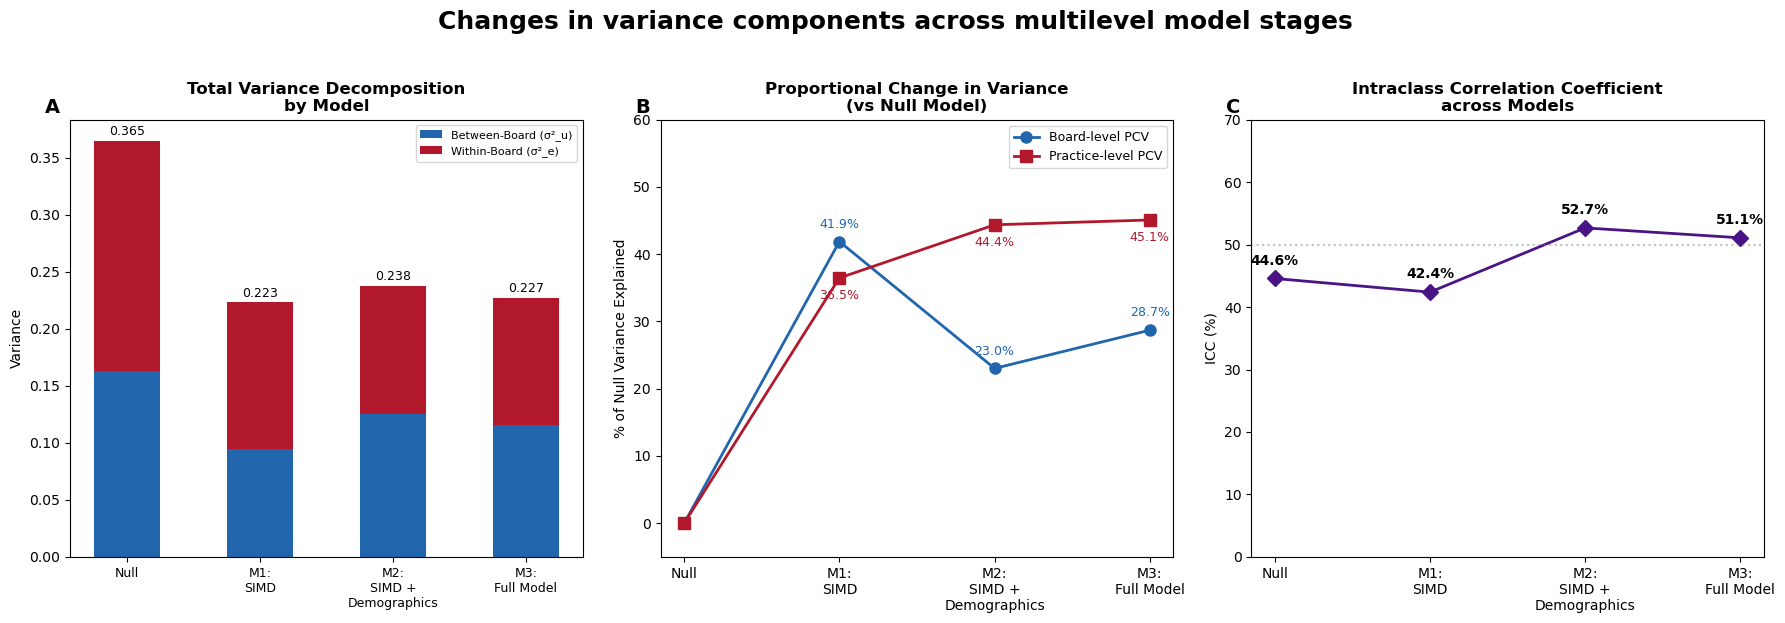

In [24]:
# ================================================================================
# CELL 1: Visualise model building in stages
# Shows how variance is progressively explained at both levels
# ================================================================================

# Collect variance components from each model
models = {
    'Null': {'board': sigma2_u_null, 'practice': sigma2_e_null},
    'M1:\nSIMD': {'board': sigma2_u_m1, 'practice': sigma2_e_m1},
    'M2:\nSIMD +\nDemographics': {'board': sigma2_u_m2, 'practice': sigma2_e_m2},
    'M3:\nFull Model': {'board': sigma2_u_m3, 'practice': sigma2_e_m3},
}

model_names = list(models.keys())
board_vars = [models[m]['board'] for m in model_names]
practice_vars = [models[m]['practice'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Stacked bar chart of variance components ---
x = np.arange(len(model_names))
width = 0.5
axes[0].bar(x, board_vars, width, label='Between-Board (σ²_u)', color='#2166ac')
axes[0].bar(x, practice_vars, width, bottom=board_vars, label='Within-Board (σ²_e)', color='#b2182b')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_ylabel('Variance')
axes[0].set_title('Total Variance Decomposition\nby Model', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].text(-0.05, 1.05, 'A', transform=axes[0].transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')
# Add total variance labels
for i in range(len(model_names)):
    total = board_vars[i] + practice_vars[i]
    axes[0].text(i, total + 0.005, f'{total:.3f}', ha='center', fontsize=9)

# --- Plot 2: PCV at each level ---
board_pcvs = [0, pcv_board_m1 * 100, pcv_board_m2 * 100, pcv_board_m3 * 100]
practice_pcvs = [0, pcv_practice_m1 * 100, pcv_practice_m2 * 100, pcv_practice_m3 * 100]
axes[1].plot(model_names, board_pcvs, 'o-', color='#2166ac', linewidth=2,
             markersize=8, label='Board-level PCV')
axes[1].plot(model_names, practice_pcvs, 's-', color='#b2182b', linewidth=2,
             markersize=8, label='Practice-level PCV')
axes[1].set_ylabel('% of Null Variance Explained')
axes[1].set_title('Proportional Change in Variance\n(vs Null Model)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(-5, 60)
axes[1].text(-0.05, 1.05, 'B', transform=axes[1].transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')
# Add percentage labels
for i, (b, p) in enumerate(zip(board_pcvs, practice_pcvs)):
    if i > 0:
        axes[1].annotate(f'{b:.1f}%', (i, b), textcoords="offset points",
                         xytext=(0, 10), ha='center', fontsize=9, color='#2166ac')
        axes[1].annotate(f'{p:.1f}%', (i, p), textcoords="offset points",
                         xytext=(0, -15), ha='center', fontsize=9, color='#b2182b')

# --- Plot 3: ICC across models ---
iccs = [
    icc_null * 100,
    sigma2_u_m1 / (sigma2_u_m1 + sigma2_e_m1) * 100,
    sigma2_u_m2 / (sigma2_u_m2 + sigma2_e_m2) * 100,
    sigma2_u_m3 / (sigma2_u_m3 + sigma2_e_m3) * 100,
]
axes[2].plot(model_names, iccs, 'D-', color='#4a1486', linewidth=2, markersize=8)
axes[2].set_ylabel('ICC (%)')
axes[2].set_title('Intraclass Correlation Coefficient\nacross Models', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 70)
axes[2].axhline(y=50, color='grey', linestyle=':', alpha=0.5)
axes[2].text(-0.05, 1.05, 'C', transform=axes[2].transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')
for i, v in enumerate(iccs):
    axes[2].annotate(f'{v:.1f}%', (i, v), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Changes in variance components across multilevel model stages',
             fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/MLM_Model_Building.png",
            dpi=300, bbox_inches='tight')
plt.show()

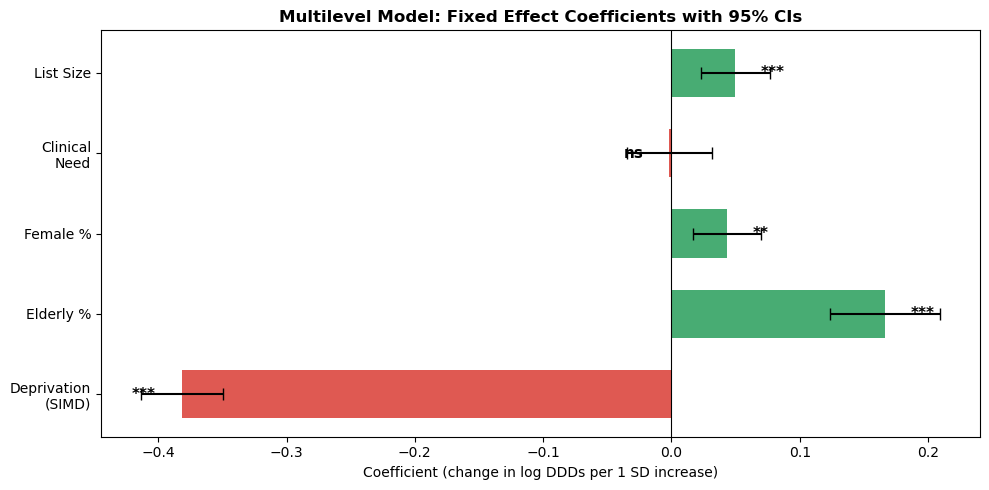

In [26]:
# ================================================================================
# CELL 2: Visualise fixed effect coefficients from the full model
# Shows the relative strength and direction of each predictor
# ================================================================================
predictors = ['Weighted_SIMD_z', 'Elderly_Pct_z', 'Overall_Pct_Female_z',
              'Clinical_Need_Composite_z', 'PracticeListSize_z']
labels = ['Deprivation\n(SIMD)', 'Elderly %', 'Female %', 'Clinical\nNeed', 'List Size']

coefs = [model3.fe_params[p] for p in predictors]
ses = [model3.bse[p] for p in predictors]
ci_lower = [c - 1.96 * s for c, s in zip(coefs, ses)]
ci_upper = [c + 1.96 * s for c, s in zip(coefs, ses)]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027' if c < 0 else '#1a9850' for c in coefs]
y_pos = np.arange(len(predictors))

ax.barh(y_pos, coefs, color=colors, alpha=0.8, height=0.6)
ax.errorbar(coefs, y_pos, xerr=[[c - l for c, l in zip(coefs, ci_lower)],
            [u - c for c, u in zip(coefs, ci_upper)]],
            fmt='none', color='black', capsize=4)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Coefficient (change in log DDDs per 1 SD increase)')
ax.set_title('Multilevel Model: Fixed Effect Coefficients with 95% CIs',
             fontsize=12, fontweight='bold')

# Add significance stars
pvals = [model3.pvalues[p] for p in predictors]
for i, (c, p) in enumerate(zip(coefs, pvals)):
    star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    offset = 0.02 if c > 0 else -0.02
    ha = 'left' if c > 0 else 'right'
    ax.text(c + offset, i, star, ha=ha, va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/MLM_Coefficients.png",
            dpi=300, bbox_inches='tight')
plt.show()

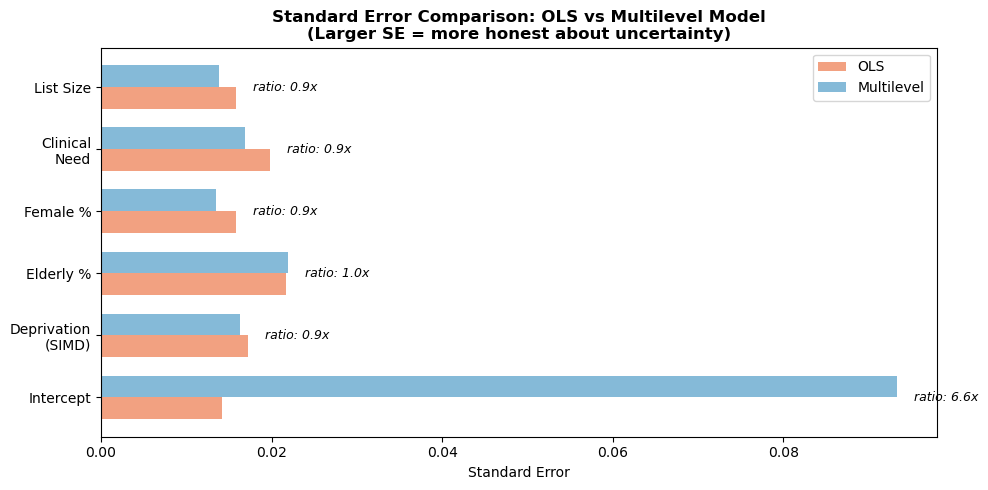

In [25]:
# ================================================================================
# CELL 3: Compare OLS vs MLM standard errors visually
# Demonstrates that OLS underestimates uncertainty for the intercept
# ================================================================================
predictors = ['Intercept', 'Weighted_SIMD_z', 'Elderly_Pct_z',
              'Overall_Pct_Female_z', 'Clinical_Need_Composite_z', 'PracticeListSize_z']
labels = ['Intercept', 'Deprivation\n(SIMD)', 'Elderly %', 'Female %',
          'Clinical\nNeed', 'List Size']

ols_ses = [ols_model.bse[p] for p in predictors]
mlm_ses = [model3.bse[p] for p in predictors]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(predictors))
width = 0.35

ax.barh(y_pos - width / 2, ols_ses, width, label='OLS', color='#ef8a62', alpha=0.8)
ax.barh(y_pos + width / 2, mlm_ses, width, label='Multilevel', color='#67a9cf', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Standard Error')
ax.set_title('Standard Error Comparison: OLS vs Multilevel Model\n'
             '(Larger SE = more honest about uncertainty)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Add ratio annotations
for i in range(len(predictors)):
    ratio = mlm_ses[i] / ols_ses[i]
    ax.text(max(ols_ses[i], mlm_ses[i]) + 0.002, i,
            f'ratio: {ratio:.1f}x', va='center', fontsize=9, style='italic')

plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/OLS_vs_MLM_SE_Comparison.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ================================================================================
# CELL 1: Visualise the Null Model
# Shows each board has its own intercept (horizontal line) but no predictors
# The overall mean is the fixed intercept; each board deviates from it
# ================================================================================

# Get null model random intercepts
null_intercept = null_model.fe_params['Intercept']
null_random = {df[df['HBT'] == k]['Board_Name'].iloc[0]: v['Group'] 
               for k, v in null_model.random_effects.items()}

fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual data points coloured by board
boards = sorted(df['Board_Name'].unique())
cmap = plt.cm.get_cmap('tab20', len(boards))
board_colors = {b: cmap(i) for i, b in enumerate(boards)}

for b in boards:
    subset = df[df['Board_Name'] == b]
    ax.scatter(subset['Weighted_SIMD_z'], subset['Log_Total_DDDs'],
               alpha=0.3, s=15, color=board_colors[b], label=b)

# Plot overall mean (fixed intercept)
ax.axhline(y=null_intercept, color='black', linewidth=2.5, linestyle='-',
           label=f'Overall mean: {null_intercept:.2f}')

# Plot each board's intercept
for b in boards:
    board_intercept = null_intercept + null_random[b]
    ax.axhline(y=board_intercept, color=board_colors[b], linewidth=1.5,
               linestyle='--', alpha=0.7)

ax.set_xlabel('Deprivation (SIMD z-score) — shown for reference, NOT in model', fontsize=10)
ax.set_ylabel('Log Total DDDs per 1,000 Registrants')
ax.set_title('Null Model: Random Intercepts Only (No Predictors)\n'
             'Each board gets its own baseline (dashed lines) around the overall mean (solid black)',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/Visual_Null_Model.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ================================================================================
# CELL 2: Visualise Model 1 — SIMD only
# Each board now has its own intercept AND a common slope for deprivation
# The slope is the same for all boards (fixed effect) but starting points differ
# ================================================================================

m1_intercept = model1.fe_params['Intercept']
m1_slope = model1.fe_params['Weighted_SIMD_z']
m1_random = {df[df['HBT'] == k]['Board_Name'].iloc[0]: v['Group']
             for k, v in model1.random_effects.items()}

fig, ax = plt.subplots(figsize=(14, 7))

x_range = np.linspace(df['Weighted_SIMD_z'].min(), df['Weighted_SIMD_z'].max(), 100)

# Plot data points
for b in boards:
    subset = df[df['Board_Name'] == b]
    ax.scatter(subset['Weighted_SIMD_z'], subset['Log_Total_DDDs'],
               alpha=0.3, s=15, color=board_colors[b], label=b)

# Plot overall fixed regression line
y_fixed = m1_intercept + m1_slope * x_range
ax.plot(x_range, y_fixed, color='black', linewidth=2.5, linestyle='-',
        label=f'Overall: {m1_intercept:.2f} + ({m1_slope:.2f} × SIMD)')

# Plot each board's line (same slope, different intercept)
for b in boards:
    board_intercept = m1_intercept + m1_random[b]
    y_board = board_intercept + m1_slope * x_range
    ax.plot(x_range, y_board, color=board_colors[b], linewidth=1.2,
            linestyle='--', alpha=0.7)

ax.set_xlabel('Deprivation (SIMD z-score)\n← More Deprived | Less Deprived →', fontsize=10)
ax.set_ylabel('Log Total DDDs per 1,000 Registrants')
ax.set_title('Model 1: SIMD Only (Random Intercept)\n'
             'All boards share the same slope but start from different baselines',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=1)
plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/Visual_Model1_SIMD.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ================================================================================
# CELL 3: Visualise Model 3 (Full Model) — predicted vs actual
# Shows how well the full model captures prescribing variation
# Colour by board to see if clustering is accounted for
# ================================================================================

m3_fitted = model3.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Predicted vs Actual ---
for b in boards:
    subset = df[df['Board_Name'] == b]
    idx = subset.index
    axes[0].scatter(m3_fitted[idx], subset['Log_Total_DDDs'],
                    alpha=0.4, s=15, color=board_colors[b], label=b)

# Perfect prediction line
min_val = min(m3_fitted.min(), df['Log_Total_DDDs'].min())
max_val = max(m3_fitted.max(), df['Log_Total_DDDs'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5,
             label='Perfect prediction')
axes[0].set_xlabel('Model 3 Predicted Log DDDs')
axes[0].set_ylabel('Actual Log DDDs')
axes[0].set_title('Full Multilevel Model: Predicted vs Actual\n'
                   '(Closer to diagonal = better fit)',
                   fontsize=11, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=6, ncol=1)

# --- Right: Fitted lines by board against SIMD ---
m3_intercept = model3.fe_params['Intercept']
m3_simd_slope = model3.fe_params['Weighted_SIMD_z']
m3_random = {df[df['HBT'] == k]['Board_Name'].iloc[0]: v['Group']
             for k, v in model3.random_effects.items()}

x_range = np.linspace(df['Weighted_SIMD_z'].min(), df['Weighted_SIMD_z'].max(), 100)

for b in boards:
    subset = df[df['Board_Name'] == b]
    axes[1].scatter(subset['Weighted_SIMD_z'], subset['Log_Total_DDDs'],
                    alpha=0.3, s=15, color=board_colors[b])

# Plot each board's line (holding other predictors at mean = 0)
for b in boards:
    board_intercept = m3_intercept + m3_random[b]
    y_board = board_intercept + m3_simd_slope * x_range
    axes[1].plot(x_range, y_board, color=board_colors[b], linewidth=1.2,
                 linestyle='--', alpha=0.7)

y_fixed = m3_intercept + m3_simd_slope * x_range
axes[1].plot(x_range, y_fixed, color='black', linewidth=2.5, label='Overall fixed line')
axes[1].set_xlabel('Deprivation (SIMD z-score)\n← More Deprived | Less Deprived →', fontsize=10)
axes[1].set_ylabel('Log Total DDDs per 1,000 Registrants')
axes[1].set_title('Full Model: SIMD Relationship by Board\n'
                   '(Other predictors held at mean)',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/Visual_Model3_Full.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ================================================================================
# CELL 4: Side-by-side comparison — Null vs Model 1 vs Full Model
# Shows visually how the model improves at capturing the data
# ================================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

x_range = np.linspace(df['Weighted_SIMD_z'].min(), df['Weighted_SIMD_z'].max(), 100)

# --- Panel 1: Null Model ---
for b in boards:
    subset = df[df['Board_Name'] == b]
    axes[0].scatter(subset['Weighted_SIMD_z'], subset['Log_Total_DDDs'],
                    alpha=0.2, s=10, color=board_colors[b])

axes[0].axhline(y=null_intercept, color='black', linewidth=2.5)
for b in boards:
    board_int = null_intercept + null_random[b]
    axes[0].axhline(y=board_int, color=board_colors[b], linewidth=1, linestyle='--', alpha=0.6)

axes[0].set_xlabel('SIMD z-score')
axes[0].set_ylabel('Log Total DDDs')
axes[0].set_title('Null Model\n(Board intercepts only, no predictors)',
                   fontsize=11, fontweight='bold')

# --- Panel 2: Model 1 (SIMD) ---
for b in boards:
    subset = df[df['Board_Name'] == b]
    axes[1].scatter(subset['Weighted_SIMD_z'], subset['Log_Total_DDDs'],
                    alpha=0.2, s=10, color=board_colors[b])

y_fixed = m1_intercept + m1_slope * x_range
axes[1].plot(x_range, y_fixed, color='black', linewidth=2.5)
for b in boards:
    board_int = m1_intercept + m1_random[b]
    y_board = board_int + m1_slope * x_range
    axes[1].plot(x_range, y_board, color=board_colors[b], linewidth=1,
                 linestyle='--', alpha=0.6)

axes[1].set_xlabel('SIMD z-score')
axes[1].set_ylabel('')
axes[1].set_title('Model 1: + Deprivation\n(Same slope, different intercepts)',
                   fontsize=11, fontweight='bold')

# --- Panel 3: Full Model ---
for b in boards:
    subset = df[df['Board_Name'] == b]
    axes[2].scatter(subset['Weighted_SIMD_z'], subset['Log_Total_DDDs'],
                    alpha=0.2, s=10, color=board_colors[b])

y_fixed_m3 = m3_intercept + m3_simd_slope * x_range
axes[2].plot(x_range, y_fixed_m3, color='black', linewidth=2.5)
for b in boards:
    board_int = m3_intercept + m3_random[b]
    y_board = board_int + m3_simd_slope * x_range
    axes[2].plot(x_range, y_board, color=board_colors[b], linewidth=1,
                 linestyle='--', alpha=0.6)

axes[2].set_xlabel('SIMD z-score')
axes[2].set_ylabel('')
axes[2].set_title('Model 3: Full Model\n(All predictors, different intercepts)',
                   fontsize=11, fontweight='bold')

# Shared legend
handles = [plt.Line2D([0], [0], color=board_colors[b], linewidth=2) for b in boards]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2.5))
labels_legend = boards + ['Overall fixed effect']
fig.legend(handles, labels_legend, bbox_to_anchor=(0.5, -0.05), loc='upper center',
           ncol=5, fontsize=7)

plt.suptitle('Multilevel Model Building: Visual Progression',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig("/Users/hugocather/MD4002 Dissertation/2024/Figures/Visual_Model_Progression.png",
            dpi=300, bbox_inches='tight')
plt.show()